# New Experiments using Datasetv2

- First run, no imputation, no standardization. 
- coarse grid search

In [9]:
import importlib
import feature_engineering as fe_module
import model as model_module
importlib.reload(fe_module)
importlib.reload(model_module)
from model import train_best_model
import os
import pandas as pd

files = [
    ("datasets/Dataset_v2/pooled_CN.csv", "CN"),
    ("datasets/Dataset_v2/pooled_MCI_AD.csv", "AD"),
]

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.001, 0.01, 0.05],
    'subsample': [0.4, 0.6, 0.8],
    'colsample_bytree': [0.4, 0.6, 0.8],
}

results_dir = "experiments/experiment_0.1/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp0_1_results = {}
exp0_1_models = {}    # { key: (model, cols, summary) }

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Grid search: {base} ({prog}) — {len(df)} samples ===")
        print(f"{'='*60}")
        model, cols, summary = train_best_model(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_0.1",
            cv_method='skf',
            n_jobs=8,
            model_base_name=base,
            save_artifacts=True,
        )
        key = f"{base}_{prog}"
        exp0_1_results[key] = pd.read_csv(csv_out)
        exp0_1_models[key]  = (model, cols, summary)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()



=== Grid search: pooled_CN (CN) — 12092 samples ===
Using StratifiedKFold with n_splits=5
Grid search: 243 hyperparameter combinations (n_jobs=8)


SKF grid search: 100%|██████████| 243/243 [04:21<00:00,  1.08s/combo]


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1984
           1       0.66      0.88      0.75       435

    accuracy                           0.90      2419
   macro avg       0.82      0.89      0.84      2419
weighted avg       0.92      0.90      0.90      2419


ROC AUC Score: 0.9408
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.897 (CI: 0.885, 0.909) range=0.023
- Precision (macro): 0.816 (CI: 0.796, 0.835) range=0.038
- Recall (macro): 0.889 (CI: 0.872, 0.905) range=0.032
- F1 (macro): 0.844 (CI: 0.827, 0.861) range=0.034
- ROC AUC: 0.941 (CI: 0.926, 0.954) range=0.028

Saved artifacts:
- Model:   experiments/experiment_0.1/pooled_CN_model_CN.pkl
- Scaler:  experiments/experiment_0.1/pooled_CN_scaler_CN.pkl
- Imputer: experiments/experiment_0.1/pooled_CN_imputer_CN.pkl
- Report:  experiments/experiment_0.1/poole

SKF grid search: 100%|██████████| 243/243 [02:32<00:00,  1.59combo/s]


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       280
           1       0.82      0.80      0.81       299

    accuracy                           0.80       579
   macro avg       0.80      0.81      0.80       579
weighted avg       0.81      0.80      0.80       579


ROC AUC Score: 0.8811
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.805 (CI: 0.774, 0.838) range=0.064
- Precision (macro): 0.805 (CI: 0.774, 0.837) range=0.063
- Recall (macro): 0.805 (CI: 0.774, 0.837) range=0.064
- F1 (macro): 0.805 (CI: 0.774, 0.837) range=0.064
- ROC AUC: 0.881 (CI: 0.852, 0.908) range=0.056

Saved artifacts:
- Model:   experiments/experiment_0.1/pooled_MCI_AD_model_AD.pkl
- Scaler:  experiments/experiment_0.1/pooled_MCI_AD_scaler_AD.pkl
- Imputer: experiments/experiment_0.1/pooled_MCI_AD_imputer_AD.pkl
- Report:  experiments/experime


Visualizations — pooled_CN_CN


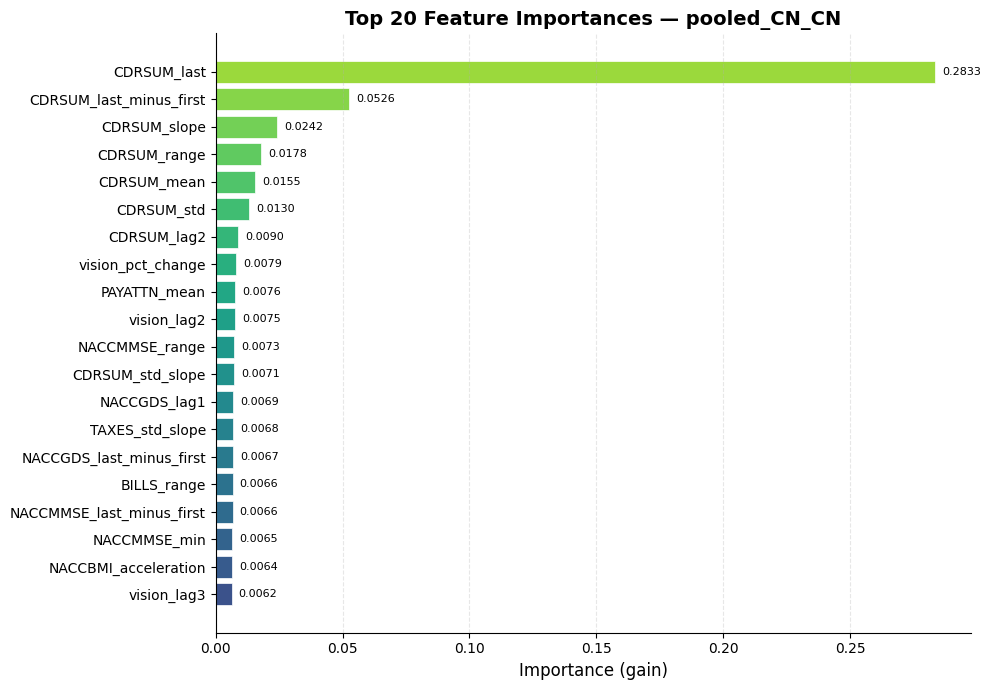

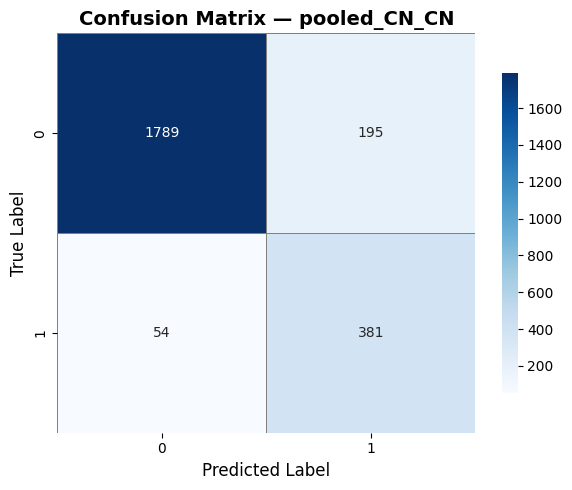

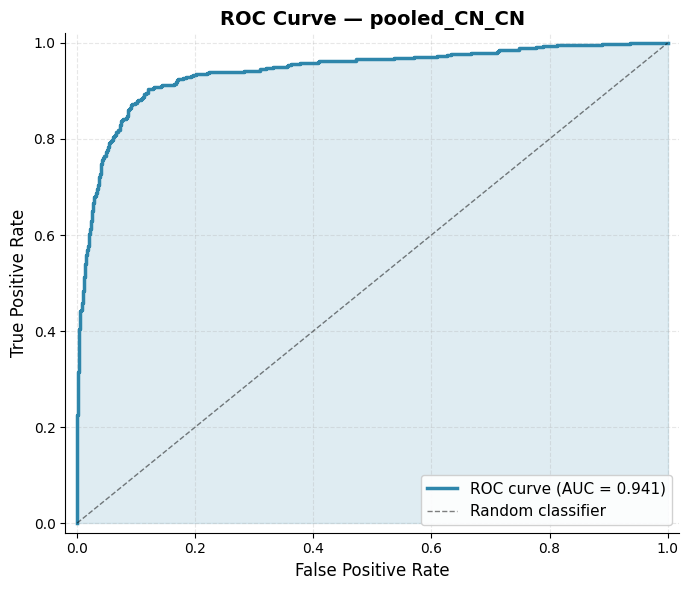


Visualizations — pooled_MCI_AD_AD


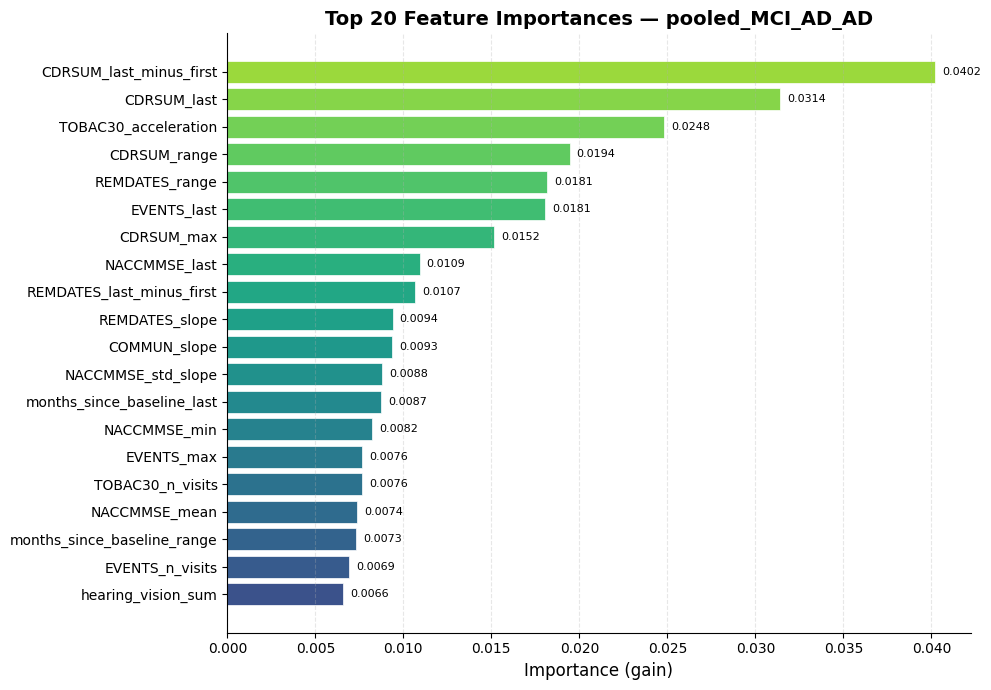

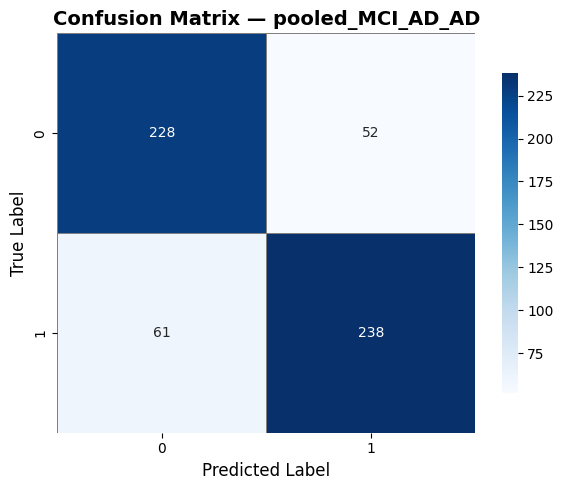

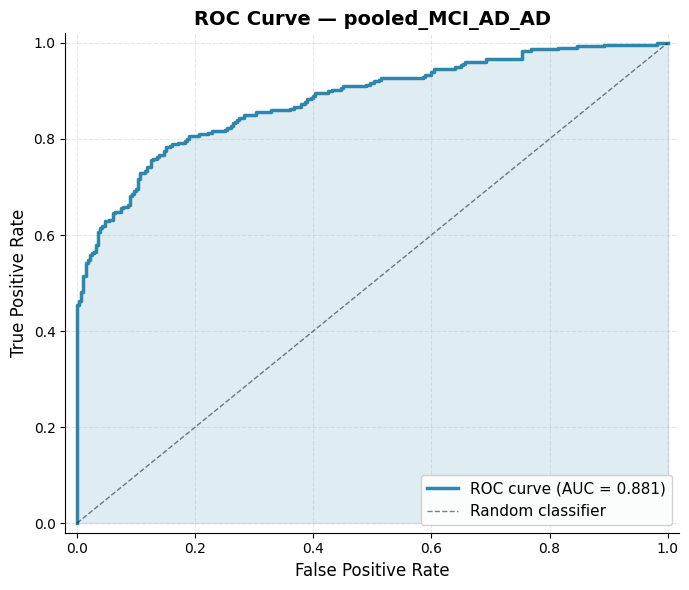

In [10]:

import importlib
import visualization as viz_module
importlib.reload(viz_module)
from visualization import plot_feature_importance, plot_confusion_mat, plot_roc
import os

charts_dir = "experiments/experiment_0.1/charts"
os.makedirs(charts_dir, exist_ok=True)

for key, (model, cols, summary) in exp0_1_models.items():
    print(f"\n{'='*60}")
    print(f"Visualizations — {key}")
    print(f"{'='*60}")

    # Feature importance
    plot_feature_importance(
        model.feature_importances_,
        cols,
        top_n=20,
        title=f"Top 20 Feature Importances — {key}",
        save_path=os.path.join(charts_dir, f"{key}_feature_importance.png"),
    )

    # Confusion matrix
    plot_confusion_mat(
        summary["y_true"],
        summary["y_pred"],
        title=f"Confusion Matrix — {key}",
        save_path=os.path.join(charts_dir, f"{key}_confusion_matrix.png"),
    )

    # ROC curve
    plot_roc(
        summary["y_true"],
        summary["y_proba"],
        title=f"ROC Curve — {key}",
        save_path=os.path.join(charts_dir, f"{key}_roc_curve.png"),
    )


# Testing out RFE code

In [6]:
import importlib
import feature_engineering as fe_module
import model as model_module
importlib.reload(fe_module)
importlib.reload(model_module)
import os
import pandas as pd
from model import train_with_rfe
rfe_results_dir = "experiments/experiment_0.2/grid_results"
os.makedirs(rfe_results_dir, exist_ok=True)

exp0_2_results = {}
exp0_2_models = {} # { key: (model, selected_features, rfecv, summary) }

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.001, 0.01, 0.05],
    'subsample': [0.4, 0.6, 0.8],
    'colsample_bytree': [0.4, 0.6, 0.8],
}
files = [
    ("datasets/Dataset_v2/pooled_CN.csv", "CN"),
    ("datasets/Dataset_v2/pooled_MCI_AD.csv", "AD"),
]
for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(rfe_results_dir, f"{base}_{prog}cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== RFE run: {base} ({prog}) — {len(df)} samples ===")
        print(f"{'='*60}")
        model, selected_features, rfecv, summary = train_with_rfe(
            df,
            progression_type=prog,
            param_grid=param_grid,
            csv_path=csv_out,
            save_dir="experiments/experiment_0.2",
            model_base_name=base,
            save_artifacts=True,
            n_jobs=8,
            rfe_step=1,
            rfe_scoring="roc_auc",
            rfe_n_jobs=4,
        )
        key = f"{base}_{prog}"
        exp0_2_results[key] = pd.read_csv(csv_out)
        exp0_2_models[key] = (model, selected_features, rfecv, summary)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()

import matplotlib.pyplot as plt

charts_dir = "experiments/experiment_0.2/charts"
os.makedirs(charts_dir, exist_ok=True)

for key, (model, selected_features, rfecv, summary) in exp0_2_models.items():
    print(f"\n{'='*60}")
    print(f"Visualizations — {key}")
    print(f"{'='*60}")

    # Feature importance
    plot_feature_importance(
        model.feature_importances_,
        selected_features,
        top_n=20,
        title=f"Top 20 Feature Importances (RFE) — {key}",
        save_path=os.path.join(charts_dir, f"{key}_feature_importance.png"),
    )

    # Confusion matrix
    plot_confusion_mat(
        summary["y_true"],
        summary["y_pred"],
        title=f"Confusion Matrix (RFE) — {key}",
        save_path=os.path.join(charts_dir, f"{key}_confusion_matrix.png"),
    )

    # ROC curve
    plot_roc(
        summary["y_true"],
        summary["y_proba"],
        title=f"ROC Curve (RFE) — {key}",
        save_path=os.path.join(charts_dir, f"{key}_roc_curve.png"),
    )

    # RFECV elimination curve
    mean_scores = rfecv.cv_results_["mean_test_score"]
    n_features_range = range(1, len(mean_scores) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(n_features_range, mean_scores, marker="o", linewidth=1.5)
    plt.axvline(rfecv.n_features_, color="red", linestyle="--", label=f"Optimal: {rfecv.n_features_}")
    plt.xlabel("Number of features selected")
    plt.ylabel("Mean CV ROC AUC")
    plt.title(f"RFECV Elimination Curve — {key}")
    plt.legend()
    plt.tight_layout()
    save_path = os.path.join(charts_dir, f"{key}_rfecv_curve.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved RFECV curve: {save_path}")


=== RFE run: pooled_CN (CN) — 12092 samples ===

Phase 1 — Coarse grid search (SKF)
Using StratifiedKFold with n_splits=5
Grid search: 243 hyperparameter combinations (n_jobs=8)


SKF grid search: 100%|██████████| 243/243 [04:25<00:00,  1.09s/combo]



Best hyperparameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.8}

Phase 2 — RFECV (step=1, scoring=roc_auc)
Starting features: 300

Optimal features selected: 241 / 300
Eliminated (59): ['SEX', 'TOBAC30_min', 'TAXES_range', 'GAMES_min', 'GAMES_std', 'GAMES_range', 'GAMES_first', 'GAMES_last', 'GAMES_last_minus_first', 'GAMES_n_visits', 'GAMES_slope', 'GAMES_acceleration', 'GAMES_std_slope', 'GAMES_pct_change', 'STOVE_mean', 'STOVE_max', 'STOVE_min', 'STOVE_std', 'STOVE_range', 'STOVE_first', 'STOVE_last', 'STOVE_last_minus_first', 'STOVE_n_visits', 'STOVE_slope', 'STOVE_acceleration', 'STOVE_std_slope', 'STOVE_pct_change', 'MEALPREP_mean', 'MEALPREP_max', 'MEALPREP_min', 'MEALPREP_std', 'MEALPREP_range', 'MEALPREP_first', 'MEALPREP_last', 'MEALPREP_last_minus_first', 'MEALPREP_n_visits', 'MEALPREP_slope', 'MEALPREP_acceleration', 'MEALPREP_std_slope', 'MEALPREP_pct_change', 'EVENTS_mean', 'EVENTS_max', 'EVENTS_min', 'COMMUN_

SKF grid search:  26%|██▌       | 63/243 [00:15<01:17,  2.34combo/s]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
SKF grid search: 100%|██████████| 243/243 [02:43<00:00,  1.49combo/s]



Best hyperparameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.6}

Phase 2 — RFECV (step=1, scoring=roc_auc)
Starting features: 300

Optimal features selected: 178 / 300
Eliminated (122): ['ALCOHOL', 'CVHATT', 'CVAFIB', 'HYPERCHO', 'HYPERTEN', 'B12DEF', 'ANX', 'NACCTBI', 'NACCBMI_n_visits', 'NACCGDS_n_visits', 'CDRSUM_n_visits', 'TOBAC30_max', 'TOBAC30_min', 'TOBAC30_std', 'TOBAC30_range', 'TOBAC30_first', 'TOBAC30_last', 'TOBAC30_last_minus_first', 'TOBAC30_slope', 'TOBAC30_std_slope', 'TOBAC30_pct_change', 'BILLS_min', 'BILLS_range', 'BILLS_first', 'BILLS_n_visits', 'BILLS_pct_change', 'TAXES_min', 'TAXES_range', 'TAXES_first', 'TAXES_last', 'TAXES_acceleration', 'TAXES_pct_change', 'SHOPPING_max', 'SHOPPING_min', 'SHOPPING_std', 'SHOPPING_range', 'SHOPPING_last', 'SHOPPING_n_visits', 'GAMES_max', 'GAMES_min', 'GAMES_range', 'GAMES_first', 'GAMES_last_minus_first', 'GAMES_n_visits', 'GAMES_pct_change', 'STOVE_max', 'STOVE_m

NameError: name 'plot_feature_importance' is not defined

- 05-26 With these results I am deciding to drop RFECV from the pipeline. Going to spend the time getting MICE implemented instead and switching